In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the CSV files

In [2]:
btc = pd.read_csv("../datasets/BTC_full_data.csv")
eth = pd.read_csv("../datasets/ETH_full_data.csv")

btc.head()
eth.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Log_Return
0,2018-01-01,755.757019,782.530029,742.004028,772.640991,772.640991,2595760128,NaN
1,2018-01-02,772.346008,914.830017,772.346008,884.443970,884.443970,5783349760,0.135145
2,2018-01-03,886.000000,974.471008,868.450989,962.719971,962.719971,5093159936,0.084803
3,2018-01-04,961.713013,1045.079956,946.085999,980.921997,980.921997,6502859776,0.018730
4,2018-01-05,975.750000,1075.390015,956.325012,997.719971,997.719971,6683149824,0.016980


# 2. Evaluation functions

In [3]:
def evaluate_strategy(strategy_returns):
    r = strategy_returns.dropna()

    # cumulative pnl
    cumulative_pnl = np.exp(r.cumsum()).iloc[-1] - 1
    # average daily pnl
    avg_daily_pnl = r.mean()
    # volatility
    volatility = r.std()
    # annualised return
    annual_return = r.mean() * 365
    # annualised volatility
    annual_vol = volatility * np.sqrt(365)
    # sharpe ratio
    rf = 0.03
    sharpe = (annual_return - rf) / annual_vol
    # max drawdown
    cumulative = np.exp(r.cumsum())
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_dd = drawdown.min()

    return {
        "Cumulative PnL": cumulative_pnl,
        "Average Daily PnL": avg_daily_pnl,
        "Volatility": volatility,
        "Annualised Return": annual_return,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd
    }


# 3. Define Bollinger Band (price level)
position = 1 → long when price is below lower band
position = -1 → short when price is above upper band
position = 0 → exit when price reverts to the rolling mean

In [4]:
def bollinger_price_csv(
    df,
    output_file,
    date_col="Date",
    price_col="Close",
    window=20,
    num_std=2
):

    df = df.copy()

    # format date
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)

    # price + log return
    df["price"] = df[price_col]
    df["log_return"] = np.log(df["price"] / df["price"].shift(1))
    df["log_return"] = df["log_return"].fillna(0)

    # Bollinger stats
    df["rolling_mean"] = df["price"].rolling(window).mean()
    df["rolling_std"] = df["price"].rolling(window).std()

    df["upper_band"] = df["rolling_mean"] + num_std * df["rolling_std"]
    df["lower_band"] = df["rolling_mean"] - num_std * df["rolling_std"]

    position = 0
    positions = []
    trades = []
    actions = []

    for i in range(len(df)):

        price = df.loc[i, "price"]
        mean = df.loc[i, "rolling_mean"]
        upper = df.loc[i, "upper_band"]
        lower = df.loc[i, "lower_band"]

        signal = 0
        action = "hold"

        if pd.isna(mean):
            position = 0

        elif position == 0:
            if price < lower:
                position = 1
                signal = 1
                action = "buy"

            elif price > upper:
                position = -1
                signal = -1
                action = "sell"

        elif position == 1:
            if price >= mean:
                position = 0
                signal = -1
                action = "sell"

        elif position == -1:
            if price <= mean:
                position = 0
                signal = 1
                action = "buy"

        positions.append(position)
        trades.append(signal)
        actions.append(action)

    df["trade"] = trades
    df["trade_action"] = actions
    df["position"] = positions
    out = df[[date_col, "price", "log_return", "trade", "trade_action", "position"]]
    out = out.rename(columns={date_col: "date"})

    # save csv
    out.to_csv(output_file, index=False)

    print(f"CSV exported → {output_file}")

    return out

# 4. Run strategy and evaluate performance

In [5]:
btc_bb = bollinger_price_csv(btc, "../datasets/btc_bollinger_post_trade_table.csv")
eth_bb = bollinger_price_csv(eth, "../datasets/eth_bollinger_post_trade_table.csv")

# Strategy returns = position * log_return (shifted)
btc_strategy_returns = (btc_bb["position"].shift(1) * btc_bb["log_return"]).dropna()
eth_strategy_returns = (eth_bb["position"].shift(1) * eth_bb["log_return"]).dropna()

btc_summary = evaluate_strategy(btc_strategy_returns)
eth_summary = evaluate_strategy(eth_strategy_returns)

# Post-trade tables: rows where a trade occurred
btc_trades = btc_bb[btc_bb["trade"] != 0].copy()
eth_trades = eth_bb[eth_bb["trade"] != 0].copy()

print("=== BTC Post-Trade Table ===")
print(btc_trades.to_string(index=False))
print("Total BTC trades: " + str(len(btc_trades)))

print("=== ETH Post-Trade Table ===")
print(eth_trades.to_string(index=False))
print("Total ETH trades: " + str(len(eth_trades)))


CSV exported → ../datasets/btc_bollinger_post_trade_table.csv
CSV exported → ../datasets/eth_bollinger_post_trade_table.csv
=== BTC Post-Trade Table ===
      date         price  log_return  trade trade_action  position
2018-02-02   8830.750000   -0.037756      1          buy         1
2018-02-14   9494.629883    0.099161     -1         sell         0
2018-03-10   8866.000000   -0.051820      1          buy         1
2018-04-12   7889.250000    0.124127     -1         sell         0
2018-04-15   8329.110352    0.042037     -1         sell        -1
2018-05-10   9043.940430   -0.030623      1          buy         0
2018-05-11   8441.490234   -0.068936      1          buy         1
2018-06-07   7678.240234    0.003165     -1         sell         0
2018-06-10   6786.020020   -0.104293      1          buy         1
2018-07-02   6614.180176    0.035136     -1         sell         0
2018-07-17   7321.040039    0.082433     -1         sell        -1
2018-08-02   7567.149902   -0.007604      1

# 5. Results table

In [6]:
results = pd.DataFrame({
    "Criteria": [
        "Cumulative PnL",
        "Average Daily PnL",
        "Volatility",
        "Annualised Return",
        "Sharpe Ratio",
        "Max Drawdown",
    ],
    "BTC": [
        btc_summary["Cumulative PnL"],
        btc_summary["Average Daily PnL"],
        btc_summary["Volatility"],
        btc_summary["Annualised Return"],
        btc_summary["Sharpe Ratio"],
        btc_summary["Max Drawdown"],
    ],
    "ETH": [
        eth_summary["Cumulative PnL"],
        eth_summary["Average Daily PnL"],
        eth_summary["Volatility"],
        eth_summary["Annualised Return"],
        eth_summary["Sharpe Ratio"],
        eth_summary["Max Drawdown"],
    ]
})

results


,Criteria,BTC,ETH
0,Cumulative PnL,-0.774877,-0.949464
1,Average Daily PnL,-0.000511,-0.001022
2,Volatility,0.026886,0.034582
3,Annualised Return,-0.186389,-0.373134
4,Sharpe Ratio,-0.421276,-0.610176
5,Max Drawdown,-0.925013,-0.970129


# 6. Plots

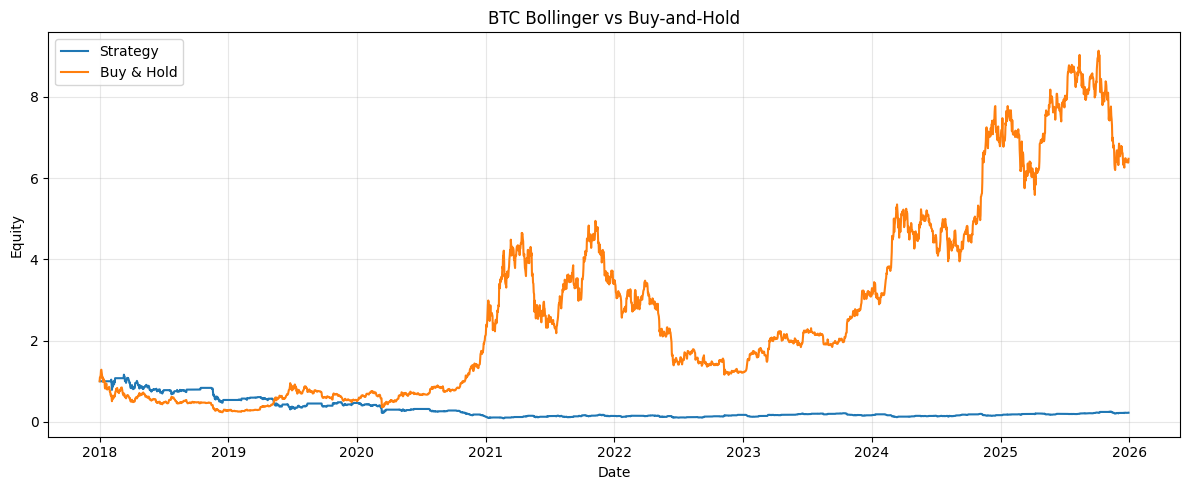

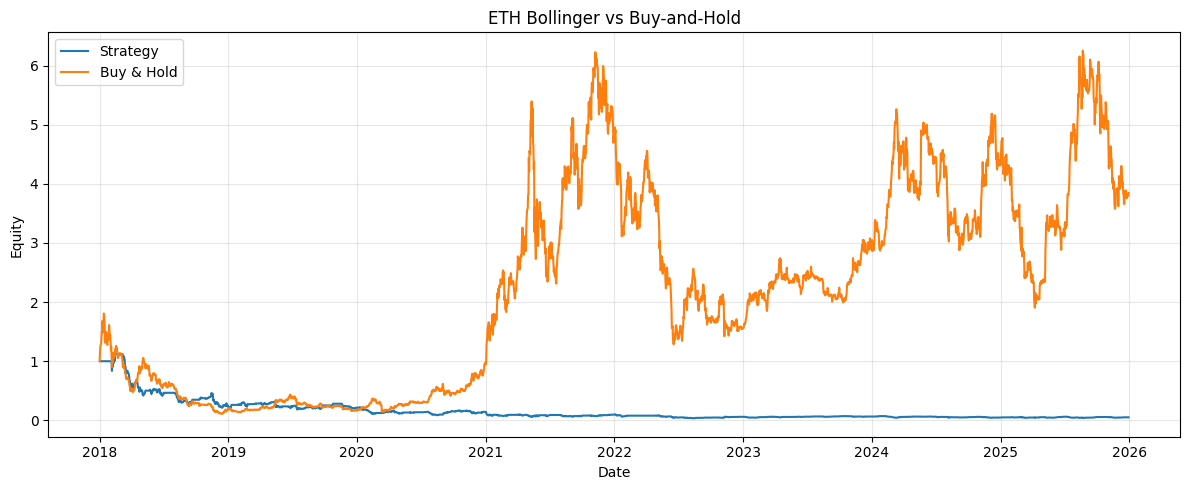

In [7]:
def plot_strategy_vs_buy_hold(bb_df, strategy_returns, date_col="date", price_col="price", title="Strategy vs Buy-and-Hold"):
    df = bb_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    df["buy_hold_ret"] = df[price_col].pct_change().fillna(0.0)
    df["buy_hold_equity"] = (1 + df["buy_hold_ret"]).cumprod()
    # strategy equity from log returns
    strat_eq = np.exp(strategy_returns.cumsum())
    strat_eq = strat_eq.reset_index(drop=True)
    plt.figure(figsize=(12, 5))
    plt.plot(df[date_col].iloc[1:len(strat_eq)+1], strat_eq, label="Strategy")
    plt.plot(df[date_col], df["buy_hold_equity"], label="Buy & Hold")
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Equity")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

plot_strategy_vs_buy_hold(btc_bb, btc_strategy_returns, title="BTC Bollinger vs Buy-and-Hold")
plot_strategy_vs_buy_hold(eth_bb, eth_strategy_returns, title="ETH Bollinger vs Buy-and-Hold")